# 2. Deploy CLM-v0.1-8B on an Amazon SageMaker AI real-time endpoint, then test and benchmark it

[CLM-v0.1-8B](https://huggingface.co/Contrastive-LM/CLM-v0.1-8B) is a contrastive "System One" model: it does
not generate text, it **scores** candidates (typed answers or free-form options) against a state.
It has two parts:

1. a frozen **Qwen3-8B** encoder that turns text into a 4096-d last-token embedding, served by **vLLM** in pooling mode, and
2. two small **projection heads** (75 MB) from the `contrastive-lm` package, which turn those embeddings into scores.

Locally the project runs these as two servers (`vllm serve` and `clm-serve`). On SageMaker both run in **one
container**, the AWS vLLM Deep Learning Container (DLC), with no custom image:

```
InvokeEndpoint ──► /invocations  (code/model.py: CLM engine, heads on CPU)
                       │  POST 127.0.0.1:8080/v1/embeddings
                       ▼
                   vLLM 0.30  --runner pooling  Qwen3-8B bf16  (GPU)
```

The DLC loads `code/model.py` from the model artifact and lets it replace the default `/invocations` route;
`/ping` stays vLLM's health check.

**Instance:** Qwen3-8B in bf16 is 16.4 GB of weights, so 24 GB of GPU memory is the smallest that fits with room for a
KV cache. Quantizing is not an option: the heads are trained on bf16 Qwen3-8B embeddings. That leaves two cheap
single-GPU choices, and this notebook asks for both in priority order:

| Priority | Instance | GPU | GPU memory | us-west-2 $/h |
|---|---|---|---|---|
| 1 | `ml.g6.xlarge` | NVIDIA L4 | 24 GB | **1.127** |
| 2 | `ml.g6.2xlarge` | NVIDIA L4 | 24 GB | 1.222 |
| 3 | `ml.g5.xlarge` | NVIDIA A10G | 24 GB | 1.408 |
| 4 | `ml.g5.2xlarge` | NVIDIA A10G | 24 GB | 1.515 |
| 5 | `ml.g6e.xlarge` | NVIDIA L40S | 48 GB | 2.605 |

All five hold the model, so the endpoint takes the cheapest one that has capacity. Single-GPU 24 GB instances are the
sweet spot: `ml.g4dn.xlarge` ($0.736) has 16 GB and no bf16 support, so it cannot run this model at all, while larger
instances pay for GPU memory and tensor parallelism an 8B encoder does not need. **Small GPU instances run out of
capacity often** — every type above failed for us at least once while writing this sample, which is exactly why the
endpoint asks for five.

**Run time:** about 45 minutes, most of it the first artifact upload (16 GB) and the endpoint start (~10 min).
**Cost:** about $1.13 per endpoint hour plus S3 storage. Run the clean-up cells at the end.

## 1. Configuration
Every external input is pinned: model revisions, the CLM source commit, and the container image tag.

In [1]:
import json, time, hashlib, io, tarfile, urllib.request, concurrent.futures as cf
from pathlib import Path
import boto3, numpy as np, pandas as pd
from botocore.config import Config

REGION = "us-east-1"
# Instance pools, cheapest first: SageMaker falls back to the next type when one has no capacity (max 5 pools).
PRICE_PER_HOUR = {"ml.g6.xlarge": 1.1267, "ml.g6.2xlarge": 1.222, "ml.g5.xlarge": 1.408,
                  "ml.g5.2xlarge": 1.515, "ml.g6e.xlarge": 2.6054}   # SageMaker on-demand, USD (same in us-east-1/us-west-2)
INSTANCE_TYPES = sorted(PRICE_PER_HOUR, key=PRICE_PER_HOUR.get)

ENCODER_ID, ENCODER_REV = "Qwen/Qwen3-8B", "b968826d9c46dd6066d109eabc6255188de91218"
HEADS_ID, HEADS_REV = "Contrastive-LM/CLM-v0.1-8B", "e939398d4556fcd9400c76fa8c5a513202f42b0a"
CLM_SRC_COMMIT = "bb42c6c5bf914fd449bed2f6ca65be80602cb1f7"          # github.com/Contrastive-LM/CLM
IMAGE = f"763104351884.dkr.ecr.{REGION}.amazonaws.com/vllm:0.30.0-gpu-py312-cu130-ubuntu24.04-sagemaker-v1.3"
INFERENCE_AMI = "al2023-ami-sagemaker-inference-gpu-4-1"             # NVIDIA 580 driver, needed by CUDA 13 images

NAME = "clm-8b"
ROLE_NAME = "clm-8b-sagemaker-execution"
ROLE_ARN = None   # set to an existing SageMaker execution role ARN to skip creating one

session = boto3.Session(region_name=REGION)
account = session.client("sts").get_caller_identity()["Account"]
BUCKET = f"sagemaker-{REGION}-{account}"
PREFIX = f"clm-8b/{ENCODER_REV[:8]}-{HEADS_REV[:8]}-{CLM_SRC_COMMIT[:7]}"   # immutable artifact path
sm, s3 = session.client("sagemaker"), session.client("s3")
smr = session.client("sagemaker-runtime", config=Config(max_pool_connections=128, read_timeout=70,
                                                        retries={"max_attempts": 1, "mode": "standard"}))
print(f"account {account}  region {REGION}  instance pools {INSTANCE_TYPES}\nartifact s3://{BUCKET}/{PREFIX}/")

account 344028372807  region us-east-1  instance pools ['ml.g6.xlarge', 'ml.g6.2xlarge', 'ml.g5.xlarge', 'ml.g5.2xlarge', 'ml.g6e.xlarge']
artifact s3://sagemaker-us-east-1-344028372807/clm-8b/b968826d-e939398d-bb42c6c/


## 2. Execution role (least privilege)
The endpoint only needs to read its artifact prefix, pull the DLC image, and write logs and metrics.
Skipped if you set `ROLE_ARN`.

In [2]:
iam = session.client("iam")
if ROLE_ARN is None:
    trust = {"Version": "2012-10-17", "Statement": [{"Effect": "Allow", "Action": "sts:AssumeRole",
             "Principal": {"Service": "sagemaker.amazonaws.com"}}]}
    policy = {"Version": "2012-10-17", "Statement": [
        {"Effect": "Allow", "Action": "s3:GetObject", "Resource": f"arn:aws:s3:::{BUCKET}/clm-8b/*"},
        {"Effect": "Allow", "Action": "s3:ListBucket", "Resource": f"arn:aws:s3:::{BUCKET}",
         "Condition": {"StringLike": {"s3:prefix": ["clm-8b/*"]}}},
        {"Effect": "Allow", "Action": "ecr:GetAuthorizationToken", "Resource": "*"},
        {"Effect": "Allow", "Action": ["ecr:BatchGetImage", "ecr:GetDownloadUrlForLayer",
                                       "ecr:BatchCheckLayerAvailability"],
         "Resource": f"arn:aws:ecr:{REGION}:763104351884:repository/vllm"},
        {"Effect": "Allow", "Action": ["logs:CreateLogGroup", "logs:CreateLogStream", "logs:PutLogEvents",
                                       "logs:DescribeLogStreams"],
         "Resource": f"arn:aws:logs:{REGION}:{account}:log-group:/aws/sagemaker/*"},
        {"Effect": "Allow", "Action": "cloudwatch:PutMetricData", "Resource": "*",
         "Condition": {"StringLike": {"cloudwatch:namespace": ["/aws/sagemaker/*", "AWS/SageMaker*"]}}}]}
    try:
        ROLE_ARN = iam.create_role(RoleName=ROLE_NAME, AssumeRolePolicyDocument=json.dumps(trust),
                                   Description="CLM-8B SageMaker endpoint")["Role"]["Arn"]
        time.sleep(10)   # let the new role propagate before SageMaker assumes it
    except iam.exceptions.EntityAlreadyExistsException:
        ROLE_ARN = iam.get_role(RoleName=ROLE_NAME)["Role"]["Arn"]
    iam.put_role_policy(RoleName=ROLE_NAME, PolicyName="clm-8b-endpoint", PolicyDocument=json.dumps(policy))
print(ROLE_ARN)

arn:aws:iam::344028372807:role/clm-8b-sagemaker-execution


## 3. Build the model artifact in S3
One **uncompressed** S3 prefix, mounted read-only at `/opt/ml/model`. Uncompressed means no tar to extract at start-up, and
because the weights come from S3 the endpoint runs with **network isolation** (no internet, no Hugging Face access).

```
/opt/ml/model/
├── config.json, tokenizer*, model-0000X-of-00005.safetensors   Qwen3-8B (vLLM loads this)
└── code/
    ├── model.py            the /invocations handler (this repo)
    ├── clm/                contrastive-lm engine, pinned commit
    └── CLM_v0.1-8B.pt      projection heads, pinned revision
```

Each step is skipped if its files are already in S3, so re-running is cheap. (In the recorded run below the 16 GB of
weights were already in the bucket, so only the 11 small `code/` objects were uploaded; a first run uploads all 24.)

In [3]:
from huggingface_hub import hf_hub_download, snapshot_download
from boto3.s3.transfer import TransferConfig

BUILD = Path("build/model"); (BUILD / "code").mkdir(parents=True, exist_ok=True)

def s3_keys(prefix):
    return {o["Key"] for p in s3.get_paginator("list_objects_v2").paginate(Bucket=BUCKET, Prefix=prefix)
            for o in p.get("Contents", [])}

# Qwen3-8B weights (16.4 GB): only the files vLLM needs
existing = s3_keys(f"{PREFIX}/")
if not any(k.endswith("model-00005-of-00005.safetensors") for k in existing):
    snapshot_download(ENCODER_ID, revision=ENCODER_REV, local_dir=BUILD,
                      allow_patterns=["*.json", "*.safetensors", "merges.txt", "vocab.json", "LICENSE"])
# CLM heads + the clm package from the pinned source commit (its static web UI is not needed)
hf_hub_download(HEADS_ID, "CLM_v0.1-8B.pt", revision=HEADS_REV, local_dir=BUILD / "code")
src = tarfile.open(fileobj=io.BytesIO(urllib.request.urlopen(
    f"https://codeload.github.com/Contrastive-LM/CLM/tar.gz/{CLM_SRC_COMMIT}").read()))
for m in src.getmembers():
    rel = m.name.split("/", 1)[1] if "/" in m.name else ""
    if rel.startswith("src/clm/") and m.isfile() and "/static/" not in rel:
        out = BUILD / "code" / rel[len("src/"):]
        out.parent.mkdir(parents=True, exist_ok=True)
        out.write_bytes(src.extractfile(m).read())
(BUILD / "code" / "model.py").write_bytes(Path("code/model.py").read_bytes())

# Upload what is missing (code/ is always re-uploaded, it is small)
cfg = TransferConfig(multipart_chunksize=64 * 2**20, max_concurrency=16)
files = [f for f in BUILD.rglob("*") if f.is_file() and ".cache" not in f.parts]
t0, sent = time.time(), 0
for f in files:
    key = f"{PREFIX}/{f.relative_to(BUILD).as_posix()}"
    if key not in existing or f.parts[2] == "code":
        s3.upload_file(str(f), BUCKET, key, Config=cfg)
        sent += 1
objects = [o for p in s3.get_paginator("list_objects_v2").paginate(Bucket=BUCKET, Prefix=f"{PREFIX}/")
           for o in p.get("Contents", [])]
print(f"s3://{BUCKET}/{PREFIX}/ holds {len(objects)} objects, {sum(o['Size'] for o in objects) / 1e9:.2f} GB "
      f"({sent} uploaded in this run, {time.time() - t0:.0f} s)")
print(sorted(f.relative_to(BUILD).as_posix() for f in files if f.parts[2] == "code"))

s3://sagemaker-us-east-1-344028372807/clm-8b/b968826d-e939398d-bb42c6c/ holds 24 objects, 16.47 GB (11 uploaded in this run, 1 s)
['code/CLM_v0.1-8B.pt', 'code/clm/__init__.py', 'code/clm/cache.py', 'code/clm/client.py', 'code/clm/embedder.py', 'code/clm/engine.py', 'code/clm/heads.py', 'code/clm/py.typed', 'code/clm/schema.py', 'code/clm/server.py', 'code/model.py']


## 4. Deploy the endpoint

| Setting | Value | Why |
|---|---|---|
| `SM_VLLM_RUNNER` | `pooling` | serve Qwen3-8B as an embedding model: last-token pooling + L2 normalise, which is what the heads were trained on |
| `SM_VLLM_MAX_MODEL_LEN` | `2048` | CLM's context length; the handler truncates to the same 2048 tokens |
| `SM_VLLM_SERVED_MODEL_NAME` | `qwen3-8b` | the name the CLM embedder asks for |
| `SAGEMAKER_MODEL_PATH` | `/opt/ml/model/code/` | where the DLC looks for the `model.py` handler |
| `CLM_DEVICE` | `cpu` | heads on CPU, so the whole GPU memory budget stays with vLLM |
| network isolation | on | the container has no internet; everything it needs is in the artifact |
| `InstancePools` | g6.xlarge, then g5.xlarge | GPU capacity is often short; SageMaker falls back to the next type instead of failing |
| routing | least outstanding requests | recommended with instance pools; sends each request to the least busy instance |
| start-up timeouts | 1200 s | 16 GB of weights plus a 22 GB image need more than the 8-minute default |

vLLM's defaults are kept otherwise: bf16, prefix caching (on by default for last-token pooling), piecewise CUDA
graphs, and `gpu-memory-utilization 0.9`. One default is worth keeping on purpose: **do not raise
`max_num_batched_tokens`**. Measured on ml.g5.xlarge with this notebook, raising it from the 2048 default cost
throughput on the `rank` workload at 64 concurrent requests: 35.6 req/s at 2048, 25.4 at 8192, 21.9 at 16384.
The KV cache on a 24 GB GPU holds about 24,000 tokens, so larger prefill batches make each step longer without
running more requests at once.

In [4]:
ENV = {
    "SM_VLLM_RUNNER": "pooling",
    "SM_VLLM_MAX_MODEL_LEN": "2048",
    "SM_VLLM_SERVED_MODEL_NAME": "qwen3-8b",
    "SAGEMAKER_MODEL_PATH": "/opt/ml/model/code/",
    "CLM_DEVICE": "cpu",
}
if NAME in [e["EndpointName"] for e in sm.list_endpoints(NameContains=NAME)["Endpoints"]]:
    raise SystemExit(f"endpoint {NAME} already exists — run the clean-up section first, or change NAME")

sm.create_model(
    ModelName=NAME, ExecutionRoleArn=ROLE_ARN, EnableNetworkIsolation=True,
    PrimaryContainer={"Image": IMAGE, "Environment": ENV,
                      "ModelDataSource": {"S3DataSource": {"S3Uri": f"s3://{BUCKET}/{PREFIX}/",
                                                           "S3DataType": "S3Prefix", "CompressionType": "None"}}})
sm.create_endpoint_config(
    EndpointConfigName=NAME,
    ProductionVariants=[{"VariantName": "AllTraffic", "ModelName": NAME, "InitialInstanceCount": 1,
                         "InstancePools": [{"InstanceType": t, "Priority": i + 1} for i, t in enumerate(INSTANCE_TYPES)],
                         "VariantInstanceProvisionTimeoutInSeconds": 600,   # per pool, before trying the next one
                         "RoutingConfig": {"RoutingStrategy": "LEAST_OUTSTANDING_REQUESTS"},
                         "InferenceAmiVersion": INFERENCE_AMI,
                         "ContainerStartupHealthCheckTimeoutInSeconds": 1200,
                         "ModelDataDownloadTimeoutInSeconds": 1200}])
sm.create_endpoint(EndpointName=NAME, EndpointConfigName=NAME)
t0 = time.time()
try:
    sm.get_waiter("endpoint_in_service").wait(EndpointName=NAME, WaiterConfig={"Delay": 30, "MaxAttempts": 120})
except Exception:
    raise SystemExit("endpoint failed: " + sm.describe_endpoint(EndpointName=NAME).get("FailureReason", "")
                     + "\nIf this is InsufficientInstanceCapacity, every pool was full. Run the clean-up section, "
                       "then retry — or add a type to PRICE_PER_HOUR (max 5 pools) or try another Region.")
pools = sm.describe_endpoint(EndpointName=NAME)["ProductionVariants"][0]["InstancePools"]
INSTANCE_TYPE = next(p["InstanceType"] for p in pools if p.get("CurrentInstanceCount"))
print(f"{NAME} InService after {(time.time() - t0) / 60:.1f} min on {INSTANCE_TYPE}  {pools}")

clm-8b InService after 11.5 min on ml.g5.xlarge  [{'InstanceType': 'ml.g5.xlarge', 'CurrentInstanceCount': 1}]


## 5. Invoke it
The body's `op` picks the CLM call, since a SageMaker endpoint only exposes `/invocations`.
The two requests below are the examples from the model card. The expected values come from an independent
reference run of the same checkpoint (Hugging Face Transformers, Qwen3-8B bf16 on CPU, last-token pooling):
`billing` 0.988, urgency 0.82, frustration 2.00, the Moon at 0.994. The endpoint should agree to about ±0.02,
the normal bf16 difference between GPU and CPU kernels. (The model card prints different example numbers, such as
`billing` 0.939; they do not come from the published `CLM_v0.1-8B.pt` on Qwen3-8B.)

In [5]:
def invoke(body: dict) -> dict:
    r = smr.invoke_endpoint(EndpointName=NAME, ContentType="application/json", Body=json.dumps(body))
    return json.loads(r["Body"].read())

card = invoke({"op": "systemone",
               "state": "Customer: my invoice was charged twice and nobody answers the phone!",
               "questions": {
                   "urgency": {"type": "noul", "instructions": "Is this urgent?"},
                   "department": {"type": "choice", "instructions": "Which team should handle this?",
                                  "criteria": {"billing": "Charges, invoices, refunds", "technical": "Bugs and outages"}},
                   "frustration": {"type": "score", "instructions": "How frustrated is the customer?",
                                   "criteria": ["Calm", "Frustrated", "Very angry"]}}})
print(json.dumps(card["answers"], indent=1))
tides = invoke({"op": "rank", "question": "What causes tides on Earth?",
                "answers": ["The Moon's gravitational pull.", "Photosynthesis in plants.", "Because the Earth is round."]})
print(json.dumps(tides["ranked"], indent=1))
REFERENCE = {"billing": 0.988, "urgency": 0.822, "frustration": 2.000, "moon": 0.994}
got = {"billing": card["answers"]["department"]["probabilities"]["billing"], "urgency": card["answers"]["urgency"]["noul"],
       "frustration": card["answers"]["frustration"]["score"], "moon": tides["ranked"][0]["prob"]}
assert tides["ranked"][0]["candidate"].startswith("The Moon")
assert all(abs(got[k] - REFERENCE[k]) < 0.02 for k in REFERENCE), got
print("matches the independent reference:", {k: round(v, 3) for k, v in got.items()})

{
 "urgency": {
  "type": "noul",
  "noul": 0.8390948015181254
 },
 "department": {
  "type": "choice",
  "choice": "billing",
  "confidence": 0.9751167393428913,
  "probabilities": {
   "billing": 0.9875583696714457,
   "technical": 0.012441630328554372
  }
 },
 "frustration": {
  "type": "score",
  "score": 1.9999776900096584,
  "confidence": 0.9999677917204006,
  "legend": {
   "0": "Calm",
   "1": "Frustrated",
   "2": "Very angry"
  },
  "probabilities": {
   "0": 8.378039419940428e-07,
   "1": 2.0634382457576035e-05,
   "2": 0.9999785278136004
  }
 }
}
[
 {
  "rank": 1,
  "candidate": "The Moon's gravitational pull.",
  "prob": 0.9928546337101066
 },
 {
  "rank": 2,
  "candidate": "Because the Earth is round.",
  "prob": 0.007116504688009085
 },
 {
  "rank": 3,
  "candidate": "Photosynthesis in plants.",
  "prob": 2.8861601884337367e-05
 }
]
matches the independent reference: {'billing': 0.988, 'urgency': 0.839, 'frustration': 2.0, 'moon': 0.993}


## 6. Answer quality on the Nova 2 Lite dataset
The dataset from `01-generate-dataset.ipynb` is labelled, so we can score the endpoint's answers. These are
**zero-shot** numbers for the reference checkpoint on a small synthetic set: a sanity check of the deployment, not a
benchmark of CLM. As the model card says, CLM's strong results come from heads fine-tuned for a task.

* **rank top-1:** how often the correct answer is ranked first among 8 (chance 12.5%).
* **urgent AUROC:** how well the urgency probability separates urgent from non-urgent tickets (0.5 = random). We use
  AUROC because zero-shot `noul` probabilities are not calibrated, so a fixed 0.5 cut-off is not meaningful.
* **department accuracy:** 5-way choice (chance 20%). Zero-shot, this checkpoint leans towards a few options.

In [6]:
rows = [json.loads(l) for l in Path("data/clm_bench.jsonl").read_text().splitlines()]
tickets = [r for r in rows if r["kind"] == "ticket"]
ranks = [r for r in rows if r["kind"] == "rank"]
DEPARTMENTS = {"billing": "Payments, charges, invoices, refunds", "technical": "Bugs, errors, outages, how-to setup",
               "account": "Login, profile, password, account settings", "shipping": "Delivery, tracking, returns",
               "sales": "Pricing, plans, upgrades, buying"}

def ticket_body(t, salt=""):
    return {"op": "systemone", "state": salt + t["text"], "questions": {
        "department": {"type": "choice", "instructions": "Which team should handle this?", "criteria": DEPARTMENTS},
        "urgent": {"type": "noul", "instructions": "Is this urgent?"},
        "frustration": {"type": "score", "instructions": "How frustrated is the customer?",
                        "criteria": ["Calm", "Frustrated", "Very angry"]}}}

def rank_body(r, salt=""):
    return {"op": "rank", "context": salt + r["context"], "question": r["question"],
            "answers": [salt + a for a in r["answers"]]}

with cf.ThreadPoolExecutor(8) as ex:
    t_out = list(ex.map(lambda t: invoke(ticket_body(t))["answers"], tickets))
    r_out = list(ex.map(lambda r: invoke(rank_body(r))["ranked"], ranks))
rank_top1 = np.mean([o[0]["candidate"] == r["answers"][r["gold"]] for o, r in zip(r_out, ranks)])
p_urgent = np.array([o["urgent"]["noul"] for o in t_out]); y = np.array([t["urgent"] for t in tickets])
urgent_auroc = np.mean([(a > b) + 0.5 * (a == b) for a in p_urgent[y] for b in p_urgent[~y]])
dept_acc = np.mean([o["department"]["choice"] == t["department"] for o, t in zip(t_out, tickets)])
print(f"rank top-1          {rank_top1:.1%}  (n={len(ranks)}, chance 12.5%)\n"
      f"urgent AUROC        {urgent_auroc:.2f}   (n={len(tickets)}, random 0.50; mean p(urgent) {p_urgent.mean():.2f})\n"
      f"department accuracy {dept_acc:.1%}  (n={len(tickets)}, chance 20%)")

rank top-1          59.4%  (n=101, chance 12.5%)
urgent AUROC        0.75   (n=120, random 0.50; mean p(urgent) 0.79)
department accuracy 32.5%  (n=120, chance 20%)


## 7. Benchmark: latency, TTFT and throughput vs concurrency

CLM returns a score distribution in one response and generates no tokens, so **time to first token (TTFT) is the time
to the first byte of the response** (TTFB). We record it when the response headers arrive and the end-to-end latency
when the body has been read; with a ~1 KB response the two are nearly equal.

Every request is a **cache miss**. CLM caches embeddings of texts it has seen before, so the benchmark prefixes each
state and candidate with a unique tag. The fixed answer options of the typed questions (department names, Yes/No, the
3-level scale) are the exception: they repeat on every request, so they are cached exactly as they would be in
production. Section 8 measures what the cache saves.

The client runs in the same Region as the endpoint. Each level sends at least 120 requests (6 per concurrent worker at
high levels) after a warm-up. `new_texts_per_s` counts the texts the encoder really embedded, and
`encoder_tok_per_s` the tokens behind them (both from the `usage` block the handler returns).

In [7]:
def timed(body):
    t0 = time.perf_counter()
    r = smr.invoke_endpoint(EndpointName=NAME, ContentType="application/json", Body=json.dumps(body))
    t1 = time.perf_counter()
    out = json.loads(r["Body"].read())
    t2 = time.perf_counter()
    return t1 - t0, t2 - t0, out

def run_level(kind, concurrency, run_id):
    data, make = (tickets, ticket_body) if kind == "ticket" else (ranks, rank_body)
    n = max(120, 6 * concurrency)
    bodies = [make(data[i % len(data)], salt=f"[{run_id}-{i}] ") for i in range(n)]
    errors, res = 0, []
    t0 = time.perf_counter()
    with cf.ThreadPoolExecutor(concurrency) as ex:
        for f in [ex.submit(timed, b) for b in bodies]:
            try:
                res.append(f.result())
            except Exception:  # noqa: BLE001  (counted, not hidden)
                errors += 1
    wall = time.perf_counter() - t0
    ttfb = np.array([r[0] for r in res]) * 1000
    e2e = np.array([r[1] for r in res]) * 1000
    # Texts the encoder actually had to embed: 1 state text per question, plus every (salted) rank candidate.
    new_texts = sum(len(b["answers"]) + 1 if kind == "rank" else 3 for b in bodies[:len(res)])
    tokens = sum(r[2]["usage"]["input_tokens"] for r in res)
    return {"workload": kind, "concurrency": concurrency, "requests": len(res), "errors": errors,
            "req_per_s": len(res) / wall, "new_texts_per_s": new_texts / wall,
            "ttft_p50_ms": np.percentile(ttfb, 50), "e2e_p50_ms": np.percentile(e2e, 50),
            "e2e_p90_ms": np.percentile(e2e, 90), "e2e_p99_ms": np.percentile(e2e, 99),
            "encoder_tok_per_s": tokens / wall}

for kind in ("ticket", "rank"):                       # warm-up (not measured)
    run_level(kind, 8, f"warm-{kind}")
bench_start = time.time()
results = [run_level(kind, c, f"{kind}-c{c}") for kind in ("ticket", "rank") for c in (1, 2, 4, 8, 16, 32, 64)]
bench_end = time.time()
bench = pd.DataFrame(results)
assert bench.errors.sum() == 0, f"{bench.errors.sum()} failed invocations"
pd.set_option("display.precision", 1)
bench

,workload,concurrency,requests,errors,req_per_s,new_texts_per_s,ttft_p50_ms,e2e_p50_ms,e2e_p90_ms,e2e_p99_ms,encoder_tok_per_s
0,ticket,1,120,0,10.6,31.9,96.6,96.7,99.8,103.6,1059.6
1,ticket,2,120,0,19.4,58.1,108.2,108.5,111.8,113.5,1931.9
2,ticket,4,120,0,33.9,101.7,108.4,108.5,153.2,156.4,3381.3
3,ticket,8,120,0,32.5,97.4,244.7,244.8,263.7,275.4,3236.7
4,ticket,16,120,0,51.6,154.7,290.7,290.8,319.6,413.9,5298.2
5,ticket,32,192,0,56.5,169.5,531.2,531.3,595.7,744.5,5952.4
6,ticket,64,384,0,56.0,168.0,1061.1,1061.1,1247.3,1615.2,5873.3
7,rank,1,120,0,6.5,58.8,151.1,151.2,160.1,163.0,776.0
8,rank,2,120,0,11.2,100.5,171.7,171.8,201.1,216.2,1325.3
9,rank,4,120,0,19.4,174.2,198.3,198.5,230.9,261.4,2298.3


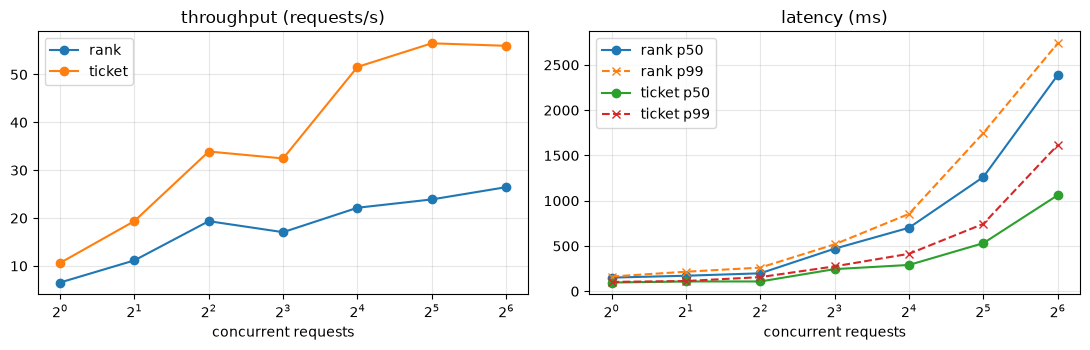

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for kind, g in bench.groupby("workload"):
    ax[0].plot(g.concurrency, g.req_per_s, "o-", label=kind)
    ax[1].plot(g.concurrency, g.e2e_p50_ms, "o-", label=f"{kind} p50")
    ax[1].plot(g.concurrency, g.e2e_p99_ms, "x--", label=f"{kind} p99")
for a, t in zip(ax, ("throughput (requests/s)", "latency (ms)")):
    a.set_xscale("log", base=2); a.set_xlabel("concurrent requests"); a.set_title(t); a.grid(alpha=.3); a.legend()
plt.tight_layout(); plt.show()

**How to read it:** throughput climbs while vLLM batches more requests per GPU step, then flattens once the GPU is
saturated; past that point extra concurrency only adds queueing latency. Pick the concurrency at the knee for your
latency budget, and use it as the per-instance autoscaling target.

## 8. Candidate count and the CLM vector cache
A `rank` call with N candidates embeds N+1 texts. CLM caches the embedding of every text it has seen, so an agent that
reuses its action set only pays for the new state. Below, each N is sent cold (all texts new) and then warm (same
candidates, new state).

In [9]:
pool = sorted({a for r in ranks for a in r["answers"]})
scale = []
for n in (8, 64, 256, 1024):
    cands = [f"[scale-{n}] {pool[i % len(pool)]} ({i})" for i in range(n)]
    cold = timed({"op": "rank", "context": f"[scale-{n}-a] A user asks for help.", "question": "What should the agent do?",
                  "answers": cands})
    warm = timed({"op": "rank", "context": f"[scale-{n}-b] A user asks for help.", "question": "What should the agent do?",
                  "answers": cands})
    scale.append({"candidates": n, "request_kb": len(json.dumps(cands)) / 1024,
                  "cold_ms": cold[1] * 1000, "warm_ms": warm[1] * 1000, "speed-up": cold[1] / warm[1]})
pd.DataFrame(scale)

,candidates,request_kb,cold_ms,warm_ms,speed-up
0,8,0.3,189.7,53.3,3.6
1,64,2.1,483.7,55.5,8.7
2,256,10.0,1776.2,55.4,32.1
3,1024,40.0,6936.5,62.2,111.5


## 9. Server-side metrics from Amazon CloudWatch
`ModelLatency` is time spent in the container; `OverheadLatency` is SageMaker's own share. GPU, CPU and memory
utilisation show which resource limits throughput. Metrics arrive with a 1-2 minute delay; the cell waits for them.

In [10]:
cw = session.client("cloudwatch")
time.sleep(150)
def metric(name, namespace, stat="Maximum"):
    dims = [{"Name": "EndpointName", "Value": NAME}, {"Name": "VariantName", "Value": "AllTraffic"}]
    for d in (dims, dims + [{"Name": "InstanceType", "Value": INSTANCE_TYPE}]):   # pooled endpoints add InstanceType
        r = cw.get_metric_statistics(Namespace=namespace, MetricName=name, StartTime=bench_start - 60,
                                     EndTime=bench_end + 60, Period=60, Statistics=[stat], Dimensions=d)
        if v := [p[stat] for p in r["Datapoints"]]:
            return max(v)
    return float("nan")
server = pd.DataFrame([
    ("ModelLatency, average (ms)", metric("ModelLatency", "AWS/SageMaker", "Average") / 1000),
    ("OverheadLatency, average (ms)", metric("OverheadLatency", "AWS/SageMaker", "Average") / 1000),
    ("GPUUtilization, max (%)", metric("GPUUtilization", "/aws/sagemaker/Endpoints")),
    ("GPUMemoryUtilization, max (%)", metric("GPUMemoryUtilization", "/aws/sagemaker/Endpoints")),
    ("CPUUtilization, max (%, 100 per vCPU)", metric("CPUUtilization", "/aws/sagemaker/Endpoints")),
    ("MemoryUtilization, max (%)", metric("MemoryUtilization", "/aws/sagemaker/Endpoints")),
    ("Invocation5XXErrors, max per minute", metric("Invocation5XXErrors", "AWS/SageMaker", "Sum")),
], columns=["metric", "value"])
server

,metric,value
0,"ModelLatency, average (ms)",1221.7
1,"OverheadLatency, average (ms)",6.0
2,"GPUUtilization, max (%)",100.0
3,"GPUMemoryUtilization, max (%)",86.3
4,"CPUUtilization, max (%, 100 per vCPU)",96.4
5,"MemoryUtilization, max (%)",26.6
6,"Invocation5XXErrors, max per minute",0.0


## 10. Cost per request
At the best measured throughput, with one instance running all hour.

In [11]:
best = bench.loc[bench.groupby("workload").req_per_s.idxmax()]
cost = best[["workload", "concurrency", "req_per_s", "e2e_p50_ms"]].assign(
    usd_per_million_requests=PRICE_PER_HOUR[INSTANCE_TYPE] / (best.req_per_s * 3600) * 1e6)
cost

,workload,concurrency,req_per_s,e2e_p50_ms,usd_per_million_requests
13,rank,64,26.5,2387.4,14.8
5,ticket,32,56.5,531.3,6.9


In [12]:
summary = {"instance": INSTANCE_TYPE, "price_per_hour": PRICE_PER_HOUR[INSTANCE_TYPE],
           "quality": {"rank_top1": rank_top1, "urgent_auroc": urgent_auroc, "department": dept_acc},
           "bench": bench.to_dict("records"), "scale": scale, "server": dict(server.values)}
# write_text returns the number of bytes written, which is what the cell prints.
Path(f"results-{INSTANCE_TYPE}.json").write_text(json.dumps(summary, indent=1, default=float))

6203

## 11. Production next steps (optional)
* **Autoscaling.** Track `SageMakerVariantInvocationsPerInstance`, with the target set from the knee of the throughput
  curve in section 7 (requests/s × 60 × ~0.7 headroom). For example:
  ```python
  aas = session.client("application-autoscaling")
  rid = f"endpoint/{NAME}/variant/AllTraffic"
  aas.register_scalable_target(ServiceNamespace="sagemaker", ResourceId=rid,
                               ScalableDimension="sagemaker:variant:DesiredInstanceCount", MinCapacity=1, MaxCapacity=4)
  aas.put_scaling_policy(PolicyName=f"{NAME}-ipi", ServiceNamespace="sagemaker", ResourceId=rid,
                         ScalableDimension="sagemaker:variant:DesiredInstanceCount", PolicyType="TargetTrackingScaling",
                         TargetTrackingScalingPolicyConfiguration={"TargetValue": 3000.0, "PredefinedMetricSpecification":
                             {"PredefinedMetricType": "SageMakerVariantInvocationsPerInstance"}})
  ```
* **Scale to zero** for spiky or dev traffic: deploy the same model as an *inference component* with `MinInstanceCount=0`.
* **Fine-tuned heads** (e.g. the DeepSWE verifier heads) are another `*.pt` file: add it under `code/` and send
  `"model": "<file stem>"`; the engine serves every head it is given, on the same encoder.
* **Private networking:** add `VpcConfig` to `create_model` with an S3 gateway endpoint; network isolation already blocks egress.

## 12. Clean up
Uncomment and run to delete the endpoint (this stops billing), the endpoint config, the model, the IAM role and the
S3 artifact.

In [13]:
# sm.delete_endpoint(EndpointName=NAME)
# sm.delete_endpoint_config(EndpointConfigName=NAME)
# sm.delete_model(ModelName=NAME)
# for p in s3.get_paginator("list_objects_v2").paginate(Bucket=BUCKET, Prefix="clm-8b/"):
#     if p.get("Contents"):
#         s3.delete_objects(Bucket=BUCKET, Delete={"Objects": [{"Key": o["Key"]} for o in p["Contents"]]})
# if ROLE_ARN.endswith(f"role/{ROLE_NAME}"):          # only the role this notebook created
#     iam.delete_role_policy(RoleName=ROLE_NAME, PolicyName="clm-8b-endpoint")
#     iam.delete_role(RoleName=ROLE_NAME)
# print("deleted")